In [1]:
# Libraries
import sys
sys.path.append('../')

import numpy as np
import matplotlib.pyplot as plt
import json
import torch
from torch import nn
from data_processors import *
from scipy.stats import sem, t
import os
from tqdm import tqdm
from policies import DeepGaussianPolicy
from envs import PendulumEnv
from data_processors import KernelDataProcessor
import copy
import math
import imageio
import random
import pandas as pd
import seaborn as sns

/home/tedeschi_bpo/miniconda3/envs/RlEnv/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Funzione per caricare i dati da un percorso
def load_trials(base_path, n_exp):
    trial_performances = []
    for i in range(n_exp):
        trial_path = os.path.join(base_path, f"trial_{i}")
        if os.path.isdir(trial_path):
            try:
                file_path = os.path.join(trial_path, "results.json")
                with open(file_path, 'r') as file:
                    data = json.load(file)
                    trial_performances.append(data["performance"])
            except (FileNotFoundError, json.JSONDecodeError) as e:
                print(f"Errore nel leggere {file_path}: {e}")
    return np.array(trial_performances)  # Converte in array per calcoli successivi

In [3]:
paths = [
    "/home/tedeschi_bpo/learn_RL/results/pendulum_friction/provakl_cono_retrain/std{0.75}kl{0}_07_28-22_23_PG_200_pendulum_200_099_constant_001_100_noclip__deep_gaussian_3375_std_075_noise_00",
    "/home/tedeschi_bpo/learn_RL/results/pendulum_friction/provakl_cono_retrain/std{0.75}kl{0}_07_29-01_03_PG_200_pendulum_200_099_constant_001_100_noclip__deep_gaussian_3375_std_075_noise_00",
    "/home/tedeschi_bpo/learn_RL/results/pendulum_friction/provakl_cono_retrain/std{5}kl{0}decay_07_29-16_33_PG_200_pendulum_200_099_constant_001_100_noclip__deep_gaussian_3375_std_5_noise_00",
    "/home/tedeschi_bpo/learn_RL/results/pendulum_friction/prova_like_lifelong/p005std{1}kl{0}_08_01-01_41_PG_200_pendulum_200_099_constant_001_100_noclip__deep_gaussian_3375_std_1_noise_00"
]

In [4]:
# Lista per memorizzare le performance per ogni set
all_performances = []

for path in paths:
    performances = load_trials(path, n_exp=10)
    if performances.size > 0:
        all_performances.append(performances)

lab = ['std 0.75', 'random down', 'decay', 'p0.005']
print(len(all_performances))

4


-88.4825667307461
-360.14573026614613
-89.7844490341418
-10.798823046970483


<Figure size 640x480 with 0 Axes>

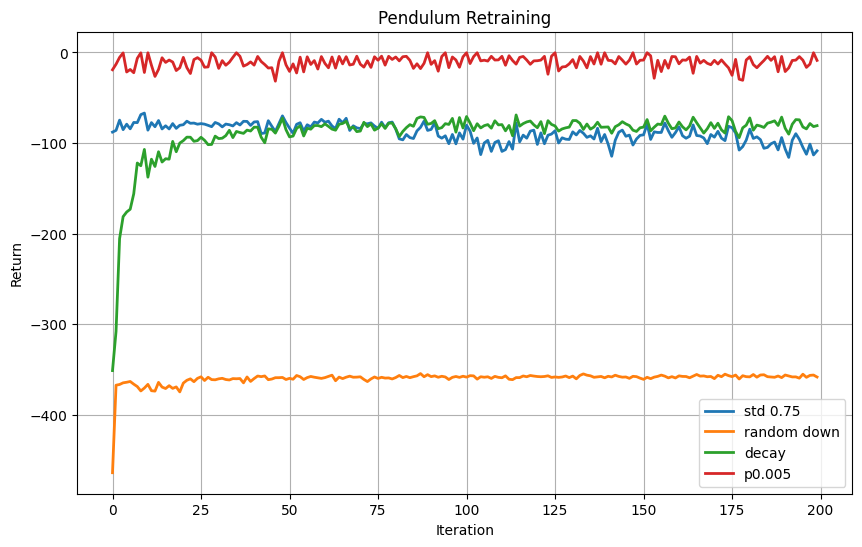

In [5]:
# Plot dei grafici
plt.clf()
# plt.figure(figsize=(6.5, 4.5))
plt.figure(figsize=(10, 6))

for i, performances in enumerate(all_performances):
    if performances.size > 0:
         # Calcola la media e gli intervalli di confidenza
        mean_performance = np.mean(performances, axis=0)
        std_performance = np.std(performances, axis=0)

        # Plot della curva media
        plt.plot(mean_performance, linewidth=2, label = lab[i])

        # Plot dell'intervallo di confidenza
        lower = mean_performance-(std_performance)*1.96/np.sqrt(performances.shape[0])
        higher = mean_performance+(std_performance)*1.96/np.sqrt(performances.shape[0])

        plt.fill_between(
            range(len(mean_performance)),
            lower,
            higher,
            alpha=0.2
        )

        print(np.mean(mean_performance))
        # print(np.mean(lower))
        # print(np.mean(higher))

# Etichette e titolo
plt.title("Pendulum Retraining")
plt.xlabel("Iteration")
plt.ylabel("Return")

plt.legend()
plt.grid()
# plt.ylim(bottom=-80)
# plt.xlim(right=80)
# Salva e mostra il grafico
# plt.savefig("dam_1825_b10_g999.pdf", format='pdf')
plt.show()

In [3]:
def load_cost(trial_path):
    costs = []
    if os.path.isdir(trial_path):
        try:
            file_path = os.path.join(trial_path, "results.json")
            with open(file_path, 'r') as file:
                data = json.load(file)
                costs.append(data["cost"])
        except (FileNotFoundError, json.JSONDecodeError) as e:
            print(f"Errore nel leggere {file_path}: {e}")
    return np.array(costs)  

In [ ]:
HORIZON = 200
GAMMA = 0.99
FRICTION = 0.3
STD_DEV = 0.25

NUM_EPISODES = 200

START = "down"
SEED = 42  
random.seed(SEED)
np.random.seed(SEED)

env =  PendulumEnv(horizon=HORIZON, gamma=GAMMA, friction = FRICTION, render_mode="rgb_array")
s_dim = 15*15*15
a_dim = env.action_dim

net = nn.Sequential(
            nn.Linear(s_dim, a_dim, bias=False),
        )
model_desc = dict(
            layers_shape=[(s_dim, a_dim)]
        )

policies = [
    # ["/home/tedeschi_bpo/learn_RL/results/pendulum_friction/provakl_cono_retrain/std{0.75}kl{0}_07_29-01_03_PG_200_pendulum_200_099_constant_001_100_noclip__deep_gaussian_3375_std_075_noise_00/trial_0", 0.75, 0],
    # ["/home/tedeschi_bpo/learn_RL/results/pendulum_friction/prova_like_lifelong/p005std{1}kl{0}_08_01-01_41_PG_200_pendulum_200_099_constant_001_100_noclip__deep_gaussian_3375_std_1_noise_00/trial_0", 1, 0],
    # ["/home/tedeschi_bpo/learn_RL/results/pendulum_friction/prova_like_lifelong/p004std{0.75}kl{0}_08_12-00_49_PG_200_pendulum_200_099_constant_0001_100_noclip__deep_gaussian_3375_std_075_noise_00/trial_0", 0.75, 0],
    # ["/home/tedeschi_bpo/learn_RL/results/pendulum_friction/prova_like_lifelong/p0045std{1}kl{0}_08_12-15_43_PG_200_pendulum_200_099_constant_0001_100_noclip__deep_gaussian_3375_std_1_noise_00/trial_0", 1, 0],
    # ["/home/tedeschi_bpo/learn_RL/results/pendulum_friction/prova_like_lifelong/p0045std{0.75}kl{0}_08_12-13_57_PG_200_pendulum_200_099_constant_0001_100_noclip__deep_gaussian_3375_std_075_noise_00/trial_0", 0.75, 0],
    # ["/home/tedeschi_bpo/learn_RL/results/pendulum_friction/prova_like_lifelong/p007std{0.75}kl{0}_08_15-18_24_PG_200_pendulum_200_099_constant_0001_100_noclip__deep_gaussian_3375_std_075_noise_00/trial_0", 0.75, 0],
    # ["/home/tedeschi_bpo/learn_RL/results/pendulum_friction/prova_like_lifelong/p007std{1}kl{0}_08_15-20_07_PG_200_pendulum_200_099_constant_0001_100_noclip__deep_gaussian_3375_std_1_noise_00/trial_0", 1, 0],
    
    ["/home/tedeschi_bpo/learn_RL/results/pendulum_friction/prova_like_lifelong/p01std{0.75}kl{0}_08_16-17_58_PG_200_pendulum_200_099_constant_0001_100_noclip__deep_gaussian_3375_std_075_noise_00/trial_0", 0.75,0],
    ["/home/tedeschi_bpo/learn_RL/results/pendulum_friction/prova_like_lifelong/p02std{0.75}kl{0}_08_16-21_41_PG_200_pendulum_200_099_constant_0001_100_noclip__deep_gaussian_3375_std_075_noise_00/trial_0", 0.75, 0],
    ["/home/tedeschi_bpo/learn_RL/results/pendulum_friction/prova_like_lifelong/p03std{0.75}kl{0}_08_16-23_10_PG_200_pendulum_200_099_constant_0001_100_noclip__deep_gaussian_3375_std_075_noise_00/trial_0", 0.75, 0],
    ["/home/tedeschi_bpo/learn_RL/results/pendulum_friction/prova_like_lifelong/p015std{0.75}kl{0}_08_17-15_05_PG_200_pendulum_200_099_constant_0001_100_noclip__deep_gaussian_3375_std_075_noise_00/trial_0", 0.75, 0],
    ["/home/tedeschi_bpo/learn_RL/results/pendulum_friction/prova_like_lifelong/p017std{0.75}kl{0}_08_18-17_45_PG_200_pendulum_200_099_constant_0001_100_noclip__deep_gaussian_3375_std_075_noise_00/trial_0", 0,0],
    
    # p0.01 lr 0.01
    #["/home/tedeschi_bpo/learn_RL/results/pendulum_friction/provakl_cono_retrain/std{0.75}kl{0}_07_29-01_03_PG_200_pendulum_200_099_constant_001_100_noclip__deep_gaussian_3375_std_075_noise_00/trial_0",0,0],

    #p0.005 lr 0.01
    #["/home/tedeschi_bpo/learn_RL/results/pendulum_friction/prova_like_lifelong/p005std{1}kl{0}_08_01-01_41_PG_200_pendulum_200_099_constant_001_100_noclip__deep_gaussian_3375_std_1_noise_00/trial_0", 0,0]


]
data = []

for policy in policies :
    random.seed(SEED)
    np.random.seed(SEED)        
    pol = DeepGaussianPolicy(
                parameters=np.load(policy[0] +"/policy_params.npy"),
                output_size=a_dim,
                model=copy.deepcopy(net),
                model_desc=copy.deepcopy(model_desc),
                std_dev=STD_DEV,
                std_decay=0,
                std_min=1e-6
            )
    dp = KernelDataProcessor()

    all_episode_rewards = []
    for i in tqdm(range(NUM_EPISODES)): # iterate over the episodes
        episode_rewards = []
        done = False
        env.reset(options={"start": START}, seed = i)
        for t in range(HORIZON): # iterate over the steps until termination
            obs = env.state
            obs = dp.transform(obs)
            action = pol.draw_action(obs)
            obs, rew, done, _ = env.step(action)
            episode_rewards.append(rew * GAMMA ** t)
            if done:
                break
        all_episode_rewards.append(sum(episode_rewards))

    mean_episode_reward = np.mean(all_episode_rewards)
    std_episode_reward = np.std(all_episode_rewards)
    print("Mean reward:", mean_episode_reward,
            "Std reward:", std_episode_reward)


    # plt.plot(all_episode_rewards, linewidth=2, label="reward")
    # plt.title("Cartpole Reward")
    # plt.xlabel("episode")
    # plt.ylabel("Return")
    # plt.grid()

    # plt.title("Pendulum Cost")
    # plt.xlabel("episode")
    # plt.ylabel("Return")
    # plt.grid()
    # plt.legend()
    # plt.show
    mean_cost = np.mean(load_cost(policy[0]))

    data.append({
        'mean_reward' : mean_episode_reward,
        'std_reward' : std_episode_reward,
        'behavioural_std' : policy[1],
        'kl_coefficient' : policy[2],
        'cost' : mean_cost

    })

df = pd.DataFrame(data)
df

 32%|███▏      | 64/200 [00:03<00:06, 19.73it/s]

In [9]:
df = pd.DataFrame(data)
df

,mean_reward,std_reward,behavioural_std,kl_coefficient,cost
0,-354.381676,10.894741,0.75,0,-35.553956
1,-364.211344,27.224106,1.00,0,-2.667581
2,-506.982209,196.941518,0.75,0,-2.259091
3,-529.245045,210.876385,1.00,0,-2.792278
4,-525.108602,205.381651,0.75,0,-2.491701


### no retraining 

  0%|          | 2/5000 [00:00<04:37, 18.04it/s]

current mu = 0


 20%|██        | 1002/5000 [00:51<03:24, 19.59it/s]

current mu = 0.1


 40%|████      | 2003/5000 [01:41<02:31, 19.72it/s]

...

current mu = 0.3


 80%|████████  | 4003/5000 [03:23<00:51, 19.54it/s]

current mu = 0.4


100%|██████████| 5000/5000 [04:14<00:00, 19.65it/s]


Mean reward: -5.060605796513284 Std reward: 50.78149016416108


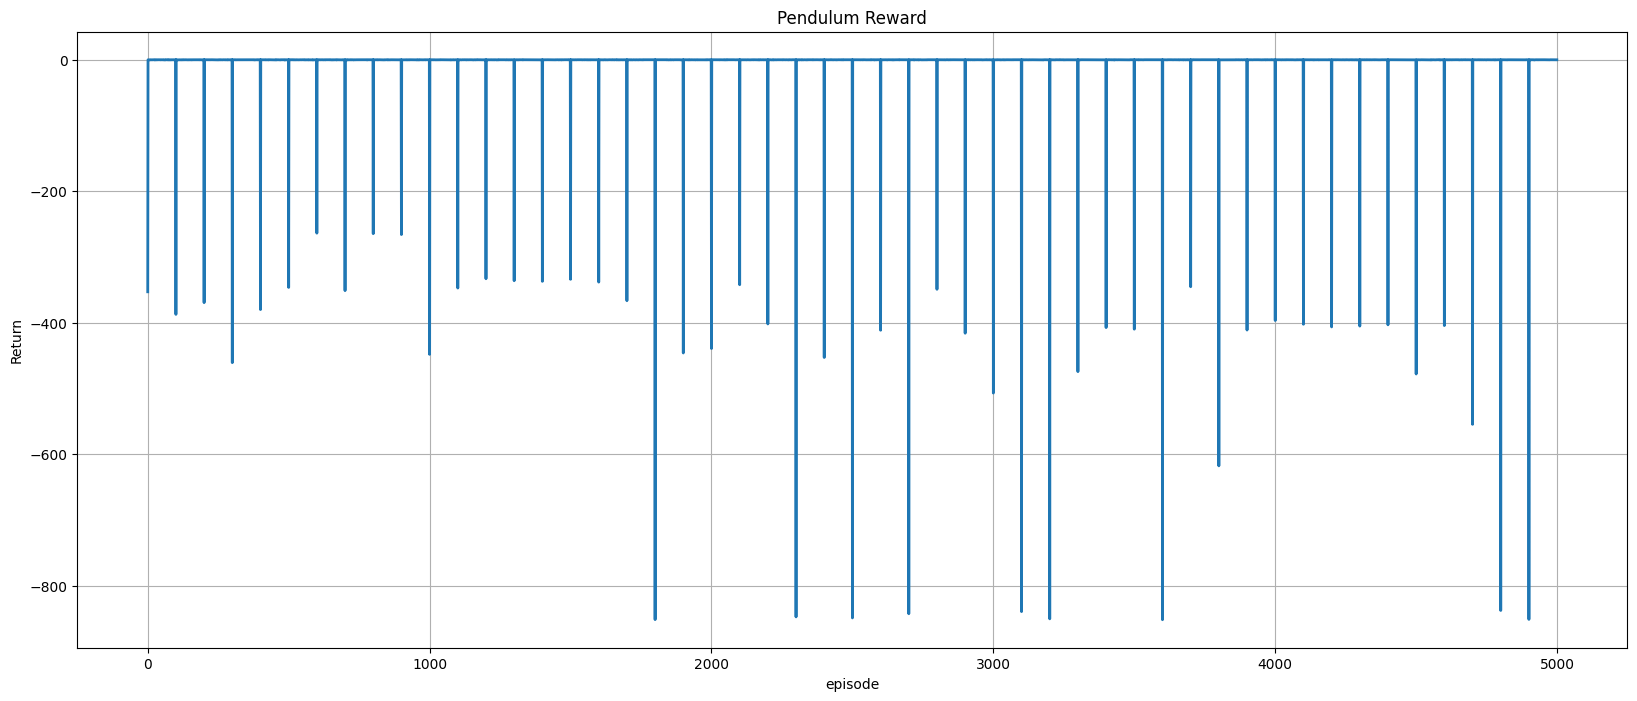

In [12]:
HORIZON = 200
GAMMA = 0.99
MU_P = 0
STD_DEV = 0.1

NUM_EPISODES = 5000

START = "up"
SEED = 42  
random.seed(SEED)
np.random.seed(SEED)

env =  PendulumEnv(horizon=HORIZON, gamma=GAMMA, friction = MU_P, render_mode="rgb_array")
s_dim = 15*15*15
a_dim = env.action_dim

net = nn.Sequential(
            nn.Linear(s_dim, a_dim, bias=False),
        )
model_desc = dict(
            layers_shape=[(s_dim, a_dim)]
        )
pol = DeepGaussianPolicy(
            parameters = np.load("/home/tedeschi_bpo/learn_RL/results/pendulum_friction/decay/test{0}_07_10-15_14_PG_200_pendulum_200_099_constant_0001_100_noclip__deep_gaussian_3375_std_1_noise_00/trial_0/policy_params.npy"),
            input_size=s_dim,
            output_size=a_dim,
            model=copy.deepcopy(net),
            model_desc=copy.deepcopy(model_desc),
            std_dev=STD_DEV,
            std_decay=0,
            std_min=1e-6
        )
dp = KernelDataProcessor()




all_episode_rewards = []
for i in tqdm(range(NUM_EPISODES)): # iterate over the episodes
    episode_rewards = []
    done = False
    if i % 1000 == 0 :
        print(f"current mu = {MU_P}")
    if i % 100 == 0:
        MU_P = round(MU_P + 0.01, 2)
        env =  PendulumEnv(horizon=HORIZON, gamma=GAMMA, friction = MU_P, render_mode="rgb_array")        
    env.reset(options={"start": "up"}, seed = i)
    if i % 100 == 0 :
        env.reset(options={"start": "down"}, seed = i)
   
    for t in range(HORIZON): # iterate over the steps until termination
        obs = env.state
        obs = dp.transform(obs)
        action = pol.draw_action(obs)
        obs, rew, done, _ = env.step(action)
        episode_rewards.append(rew * GAMMA ** t)
    all_episode_rewards.append(sum(episode_rewards))

mean_episode_reward = np.mean(all_episode_rewards)
std_episode_reward = np.std(all_episode_rewards)
print("Mean reward:", mean_episode_reward,
        "Std reward:", std_episode_reward)

plt.figure(figsize=(20, 8))
plt.plot(all_episode_rewards, linewidth=2, label="reward")
plt.title("Pendulum Reward")
plt.xlabel("episode")
plt.ylabel("Return")
plt.grid()
#plt.savefig("/home/tedeschi_bpo/learn_RL/presentation/lifelong/retrain03")



### p 0.1 down, lr 0.01

  0%|          | 0/5000 [00:00<?, ?it/s]

  0%|          | 2/5000 [00:00<04:33, 18.27it/s]

current mu = 0


 20%|██        | 1002/5000 [01:01<04:05, 16.29it/s]

current mu = 0.1


...

current mu = 0.3
 ------- Simulating retrain at mu = 0.3


 80%|████████  | 4002/5000 [03:58<00:53, 18.82it/s]

current mu = 0.4


100%|██████████| 5000/5000 [05:00<00:00, 16.66it/s]


Mean reward: -4.225343224627078 Std reward: 42.20735288893446


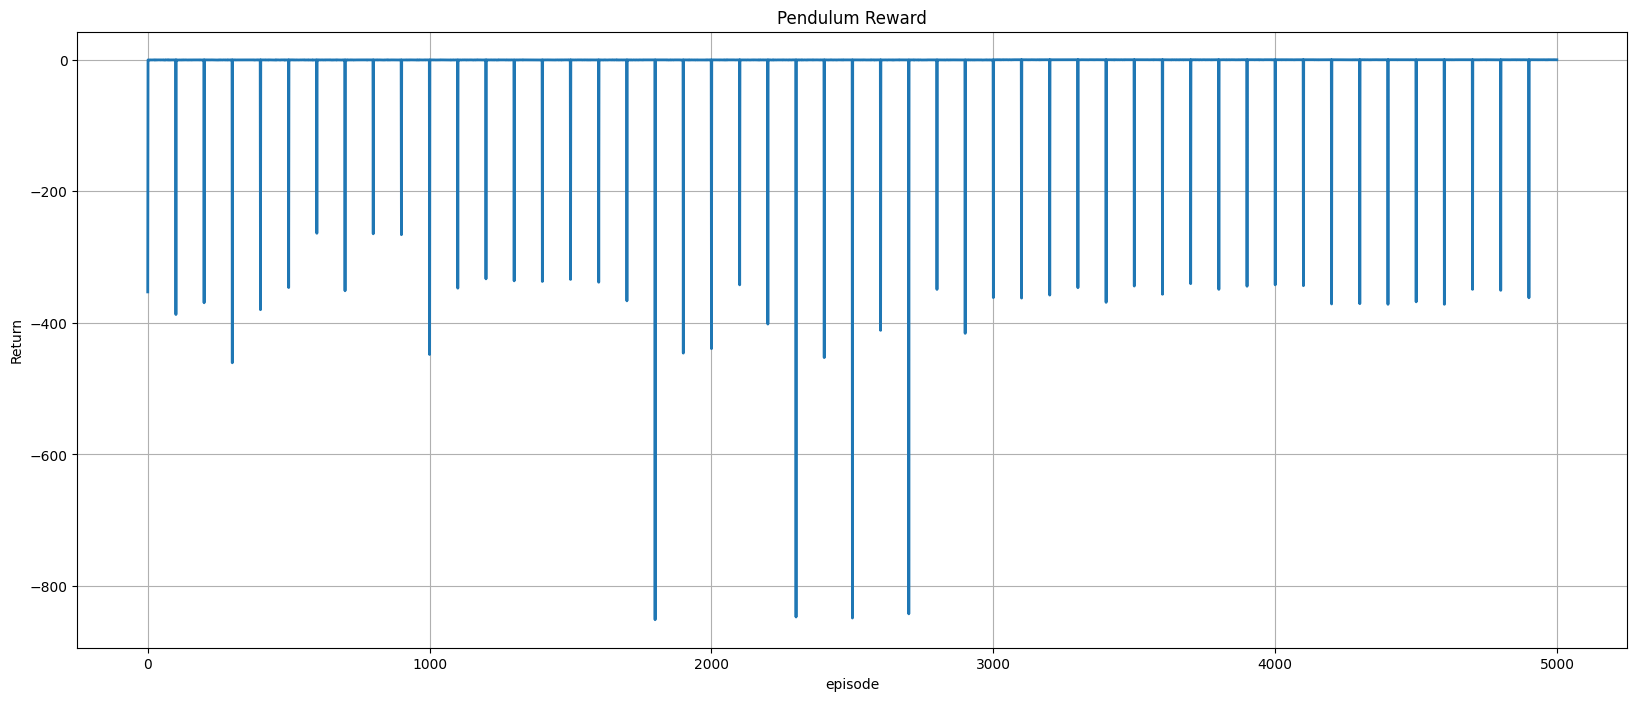

In [12]:
HORIZON = 200
GAMMA = 0.99
MU_P = 0
STD_DEV = 0.1

NUM_EPISODES = 5000

START = "up"
SEED = 42  
random.seed(SEED)
np.random.seed(SEED)

env =  PendulumEnv(horizon=HORIZON, gamma=GAMMA, friction = MU_P, render_mode="rgb_array")
s_dim = 15*15*15
a_dim = env.action_dim

net = nn.Sequential(
            nn.Linear(s_dim, a_dim, bias=False),
        )
model_desc = dict(
            layers_shape=[(s_dim, a_dim)]
        )
pol = DeepGaussianPolicy(
            parameters = np.load("/home/tedeschi_bpo/learn_RL/results/pendulum_friction/decay/test{0}_07_10-15_14_PG_200_pendulum_200_099_constant_0001_100_noclip__deep_gaussian_3375_std_1_noise_00/trial_0/policy_params.npy"),
            input_size=s_dim,
            output_size=a_dim,
            model=copy.deepcopy(net),
            model_desc=copy.deepcopy(model_desc),
            std_dev=STD_DEV,
            std_decay=0,
            std_min=1e-6
        )
dp = KernelDataProcessor()




all_episode_rewards = []
for i in tqdm(range(NUM_EPISODES)): # iterate over the episodes
    episode_rewards = []
    done = False
    if i % 1000 == 0 :
        print(f"current mu = {MU_P}")
    if i % 100 == 0:
        MU_P = round(MU_P + 0.01, 2)
        env =  PendulumEnv(horizon=HORIZON, gamma=GAMMA, friction = MU_P, render_mode="rgb_array")        
    env.reset(options={"start": "up"}, seed = i)
    if i % 100 == 0 :
        env.reset(options={"start": "down"}, seed = i)
    if i == 3000 :
        print(" ------- Simulating retrain at mu = 0.3")
        pol = DeepGaussianPolicy(
            parameters=np.load("/home/tedeschi_bpo/learn_RL/results/pendulum_friction/provakl_cono_retrain/std{0.75}kl{0}_07_29-01_03_PG_200_pendulum_200_099_constant_001_100_noclip__deep_gaussian_3375_std_075_noise_00/trial_0/policy_params.npy"),
            input_size=s_dim,
            output_size=a_dim,
            model=copy.deepcopy(net),
            model_desc=copy.deepcopy(model_desc),
            std_dev=STD_DEV,
            std_decay=0,
            std_min=1e-6
        )

    for t in range(HORIZON): # iterate over the steps until termination
        obs = env.state
        obs = dp.transform(obs)
        action = pol.draw_action(obs)
        obs, rew, done, _ = env.step(action)
        episode_rewards.append(rew * GAMMA ** t)
    all_episode_rewards.append(sum(episode_rewards))

mean_episode_reward = np.mean(all_episode_rewards)
std_episode_reward = np.std(all_episode_rewards)
print("Mean reward:", mean_episode_reward,
        "Std reward:", std_episode_reward)

plt.figure(figsize=(20, 8))
plt.plot(all_episode_rewards, linewidth=2, label="reward")
plt.title("Pendulum Reward")
plt.xlabel("episode")
plt.ylabel("Return")
plt.grid()
#plt.savefig("/home/tedeschi_bpo/learn_RL/presentation/lifelong/retrain03")



### p 0.005

  0%|          | 2/5000 [00:00<04:47, 17.40it/s]

current mu = 0


 20%|██        | 1003/5000 [00:49<03:15, 20.40it/s]

current mu = 0.1


 40%|████      | 2004/5000 [01:38<02:26, 20.41it/s]

...

current mu = 0.3
 ------- Simulating retrain at mu = 0.3


 80%|████████  | 4002/5000 [03:16<00:48, 20.49it/s]

current mu = 0.4


100%|██████████| 5000/5000 [04:04<00:00, 20.41it/s]


Mean reward: -4.384548216324144 Std reward: 43.60925719822023


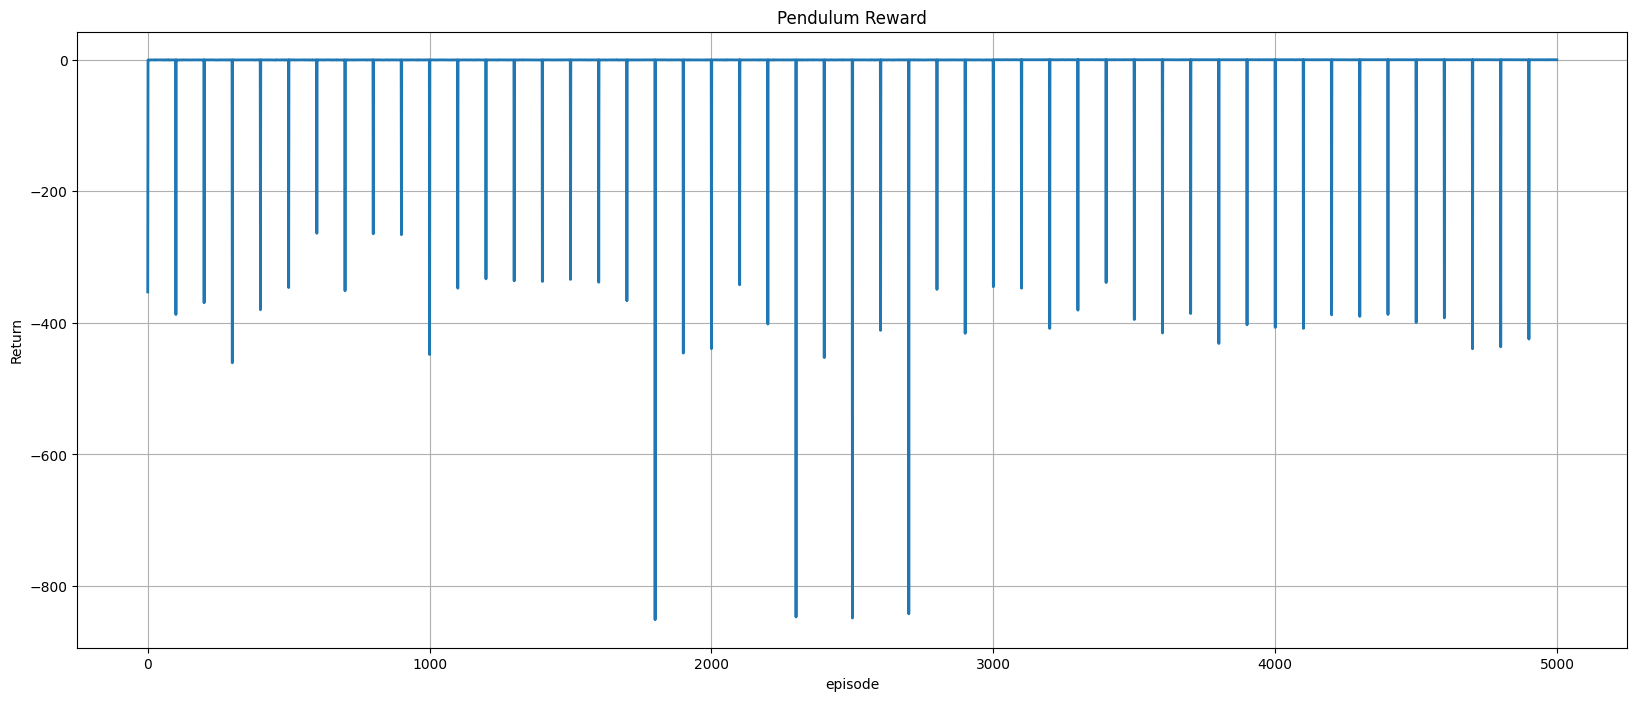

In [10]:
HORIZON = 200
GAMMA = 0.99
MU_P = 0
STD_DEV = 0.1

NUM_EPISODES = 5000

START = "up"
SEED = 42  
random.seed(SEED)
np.random.seed(SEED)

env =  PendulumEnv(horizon=HORIZON, gamma=GAMMA, friction = MU_P, render_mode="rgb_array")
s_dim = 15*15*15
a_dim = env.action_dim

net = nn.Sequential(
            nn.Linear(s_dim, a_dim, bias=False),
        )
model_desc = dict(
            layers_shape=[(s_dim, a_dim)]
        )
pol = DeepGaussianPolicy(
            parameters = np.load("/home/tedeschi_bpo/learn_RL/results/pendulum_friction/decay/test{0}_07_10-15_14_PG_200_pendulum_200_099_constant_0001_100_noclip__deep_gaussian_3375_std_1_noise_00/trial_0/policy_params.npy"),
            input_size=s_dim,
            output_size=a_dim,
            model=copy.deepcopy(net),
            model_desc=copy.deepcopy(model_desc),
            std_dev=STD_DEV,
            std_decay=0,
            std_min=1e-6
        )
dp = KernelDataProcessor()




all_episode_rewards = []
for i in tqdm(range(NUM_EPISODES)): # iterate over the episodes
    episode_rewards = []
    done = False
    if i % 1000 == 0 :
        print(f"current mu = {MU_P}")
    if i % 100 == 0:
        MU_P = round(MU_P + 0.01, 2)
        env =  PendulumEnv(horizon=HORIZON, gamma=GAMMA, friction = MU_P, render_mode="rgb_array")        
    env.reset(options={"start": "up"}, seed = i)
    if i % 100 == 0 :
        env.reset(options={"start": "down"}, seed = i)
    if i == 3000 :
        print(" ------- Simulating retrain at mu = 0.3")
        pol = DeepGaussianPolicy(
            parameters=np.load("/home/tedeschi_bpo/learn_RL/results/pendulum_friction/prova_like_lifelong/p005std{1}kl{0}_08_01-01_41_PG_200_pendulum_200_099_constant_001_100_noclip__deep_gaussian_3375_std_1_noise_00/trial_0/policy_params.npy"),
            input_size=s_dim,
            output_size=a_dim,
            model=copy.deepcopy(net),
            model_desc=copy.deepcopy(model_desc),
            std_dev=STD_DEV,
            std_decay=0,
            std_min=1e-6
        )

    for t in range(HORIZON): # iterate over the steps until termination
        obs = env.state
        obs = dp.transform(obs)
        action = pol.draw_action(obs)
        obs, rew, done, _ = env.step(action)
        episode_rewards.append(rew * GAMMA ** t)
    all_episode_rewards.append(sum(episode_rewards))

mean_episode_reward = np.mean(all_episode_rewards)
std_episode_reward = np.std(all_episode_rewards)
print("Mean reward:", mean_episode_reward,
        "Std reward:", std_episode_reward)

plt.figure(figsize=(20, 8))
plt.plot(all_episode_rewards, linewidth=2, label="reward")
plt.title("Pendulum Reward")
plt.xlabel("episode")
plt.ylabel("Return")
plt.grid()
#plt.savefig("/home/tedeschi_bpo/learn_RL/presentation/lifelong/retrain03")



### p 0.004 e lr 1e-3

  0%|          | 2/5000 [00:00<04:41, 17.76it/s]

current mu = 0


 20%|██        | 1002/5000 [00:50<03:22, 19.77it/s]

current mu = 0.1


 40%|████      | 2002/5000 [01:41<02:32, 19.60it/s]

...

current mu = 0.3
 ------- Simulating retrain at mu = 0.3


 80%|████████  | 4004/5000 [03:21<00:49, 20.05it/s]

current mu = 0.4


100%|██████████| 5000/5000 [04:11<00:00, 19.88it/s]


Mean reward: -4.828469595436498 Std reward: 49.08068404788501


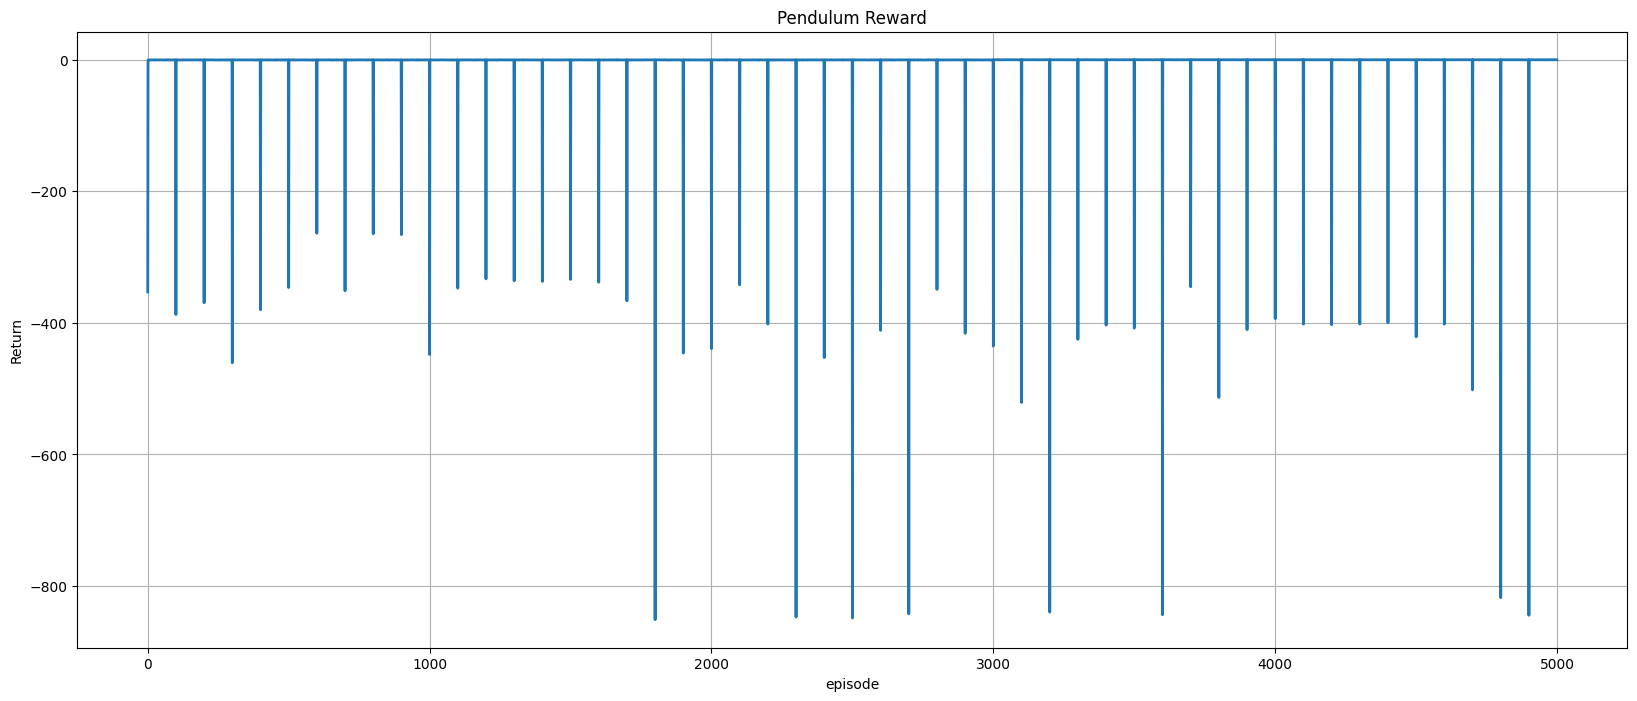

In [11]:
HORIZON = 200
GAMMA = 0.99
MU_P = 0
STD_DEV = 0.1

NUM_EPISODES = 5000

START = "up"
SEED = 42  
random.seed(SEED)
np.random.seed(SEED)

env =  PendulumEnv(horizon=HORIZON, gamma=GAMMA, friction = MU_P, render_mode="rgb_array")
s_dim = 15*15*15
a_dim = env.action_dim

net = nn.Sequential(
            nn.Linear(s_dim, a_dim, bias=False),
        )
model_desc = dict(
            layers_shape=[(s_dim, a_dim)]
        )
pol = DeepGaussianPolicy(
            parameters = np.load("/home/tedeschi_bpo/learn_RL/results/pendulum_friction/decay/test{0}_07_10-15_14_PG_200_pendulum_200_099_constant_0001_100_noclip__deep_gaussian_3375_std_1_noise_00/trial_0/policy_params.npy"),
            input_size=s_dim,
            output_size=a_dim,
            model=copy.deepcopy(net),
            model_desc=copy.deepcopy(model_desc),
            std_dev=STD_DEV,
            std_decay=0,
            std_min=1e-6
        )
dp = KernelDataProcessor()




all_episode_rewards = []
for i in tqdm(range(NUM_EPISODES)): # iterate over the episodes
    episode_rewards = []
    done = False
    if i % 1000 == 0 :
        print(f"current mu = {MU_P}")
    if i % 100 == 0:
        MU_P = round(MU_P + 0.01, 2)
        env =  PendulumEnv(horizon=HORIZON, gamma=GAMMA, friction = MU_P, render_mode="rgb_array")        
    env.reset(options={"start": "up"}, seed = i)
    if i % 100 == 0 :
        env.reset(options={"start": "down"}, seed = i)
    if i == 3000 :
        print(" ------- Simulating retrain at mu = 0.3")
        pol = DeepGaussianPolicy(
            parameters=np.load("/home/tedeschi_bpo/learn_RL/results/pendulum_friction/prova_like_lifelong/p004std{0.75}kl{0}_08_12-00_49_PG_200_pendulum_200_099_constant_0001_100_noclip__deep_gaussian_3375_std_075_noise_00/trial_0/policy_params.npy"),
            input_size=s_dim,
            output_size=a_dim,
            model=copy.deepcopy(net),
            model_desc=copy.deepcopy(model_desc),
            std_dev=STD_DEV,
            std_decay=0,
            std_min=1e-6
        )

    for t in range(HORIZON): # iterate over the steps until termination
        obs = env.state
        obs = dp.transform(obs)
        action = pol.draw_action(obs)
        obs, rew, done, _ = env.step(action)
        episode_rewards.append(rew * GAMMA ** t)
    all_episode_rewards.append(sum(episode_rewards))

mean_episode_reward = np.mean(all_episode_rewards)
std_episode_reward = np.std(all_episode_rewards)
print("Mean reward:", mean_episode_reward,
        "Std reward:", std_episode_reward)

plt.figure(figsize=(20, 8))
plt.plot(all_episode_rewards, linewidth=2, label="reward")
plt.title("Pendulum Reward")
plt.xlabel("episode")
plt.ylabel("Return")
plt.grid()
#plt.savefig("/home/tedeschi_bpo/learn_RL/presentation/lifelong/retrain03")



p0.01 lr 1e-3

  0%|          | 2/5000 [00:00<04:36, 18.05it/s]

current mu = 0


 20%|██        | 1003/5000 [00:49<03:17, 20.28it/s]

current mu = 0.1


 40%|████      | 2003/5000 [01:39<02:27, 20.29it/s]

...

current mu = 0.3
 ------- Simulating retrain at mu = 0.3


 80%|████████  | 4004/5000 [03:17<00:49, 20.23it/s]

current mu = 0.4


100%|██████████| 5000/5000 [04:14<00:00, 19.61it/s]


Mean reward: -4.777216464100381 Std reward: 48.30256407261024


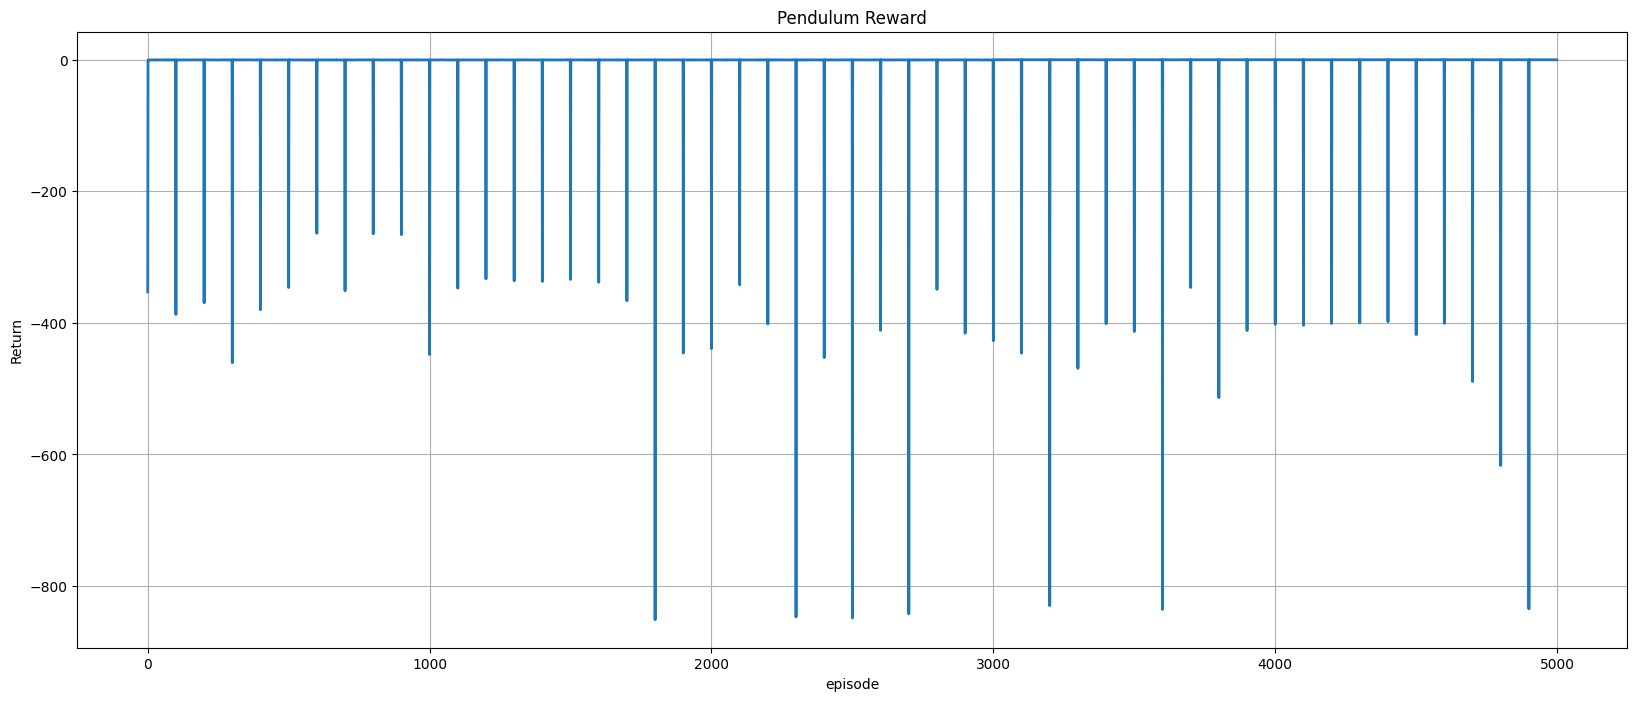

In [7]:
HORIZON = 200
GAMMA = 0.99
MU_P = 0
STD_DEV = 0.1

NUM_EPISODES = 5000

START = "up"
SEED = 42  
random.seed(SEED)
np.random.seed(SEED)

env =  PendulumEnv(horizon=HORIZON, gamma=GAMMA, friction = MU_P, render_mode="rgb_array")
s_dim = 15*15*15
a_dim = env.action_dim

net = nn.Sequential(
            nn.Linear(s_dim, a_dim, bias=False),
        )
model_desc = dict(
            layers_shape=[(s_dim, a_dim)]
        )
pol = DeepGaussianPolicy(
            parameters = np.load("/home/tedeschi_bpo/learn_RL/results/pendulum_friction/decay/test{0}_07_10-15_14_PG_200_pendulum_200_099_constant_0001_100_noclip__deep_gaussian_3375_std_1_noise_00/trial_0/policy_params.npy"),
            input_size=s_dim,
            output_size=a_dim,
            model=copy.deepcopy(net),
            model_desc=copy.deepcopy(model_desc),
            std_dev=STD_DEV,
            std_decay=0,
            std_min=1e-6
        )
dp = KernelDataProcessor()




all_episode_rewards = []
for i in tqdm(range(NUM_EPISODES)): # iterate over the episodes
    episode_rewards = []
    done = False
    if i % 1000 == 0 :
        print(f"current mu = {MU_P}")
    if i % 100 == 0:
        MU_P = round(MU_P + 0.01, 2)
        env =  PendulumEnv(horizon=HORIZON, gamma=GAMMA, friction = MU_P, render_mode="rgb_array")        
    env.reset(options={"start": "up"}, seed = i)
    if i % 100 == 0 :
        env.reset(options={"start": "down"}, seed = i)
    if i == 3000 :
        print(" ------- Simulating retrain at mu = 0.3")
        pol = DeepGaussianPolicy(
            parameters=np.load("/home/tedeschi_bpo/learn_RL/results/pendulum_friction/prova_like_lifelong/p01std{0.75}kl{0}_08_16-17_58_PG_200_pendulum_200_099_constant_0001_100_noclip__deep_gaussian_3375_std_075_noise_00/trial_0/policy_params.npy"),
            input_size=s_dim,
            output_size=a_dim,
            model=copy.deepcopy(net),
            model_desc=copy.deepcopy(model_desc),
            std_dev=STD_DEV,
            std_decay=0,
            std_min=1e-6
        )

    for t in range(HORIZON): # iterate over the steps until termination
        obs = env.state
        obs = dp.transform(obs)
        action = pol.draw_action(obs)
        obs, rew, done, _ = env.step(action)
        episode_rewards.append(rew * GAMMA ** t)
    all_episode_rewards.append(sum(episode_rewards))

mean_episode_reward = np.mean(all_episode_rewards)
std_episode_reward = np.std(all_episode_rewards)
print("Mean reward:", mean_episode_reward,
        "Std reward:", std_episode_reward)

plt.figure(figsize=(20, 8))
plt.plot(all_episode_rewards, linewidth=2, label="reward")
plt.title("Pendulum Reward")
plt.xlabel("episode")
plt.ylabel("Return")
plt.grid()
#plt.savefig("/home/tedeschi_bpo/learn_RL/presentation/lifelong/retrain03")



  0%|          | 1/5000 [00:00<09:41,  8.60it/s]

current mu = 0


 20%|██        | 1002/5000 [01:09<04:33, 14.60it/s]

current mu = 0.1


 40%|████      | 2002/5000 [02:15<03:46, 13.26it/s]

...

current mu = 0.3
 ------- Simulating retrain at mu = 0.3


 80%|████████  | 4002/5000 [04:43<00:59, 16.88it/s]

current mu = 0.4


100%|██████████| 5000/5000 [05:54<00:00, 14.11it/s]


Mean reward: -4.380053552086274 Std reward: 43.646891236395916


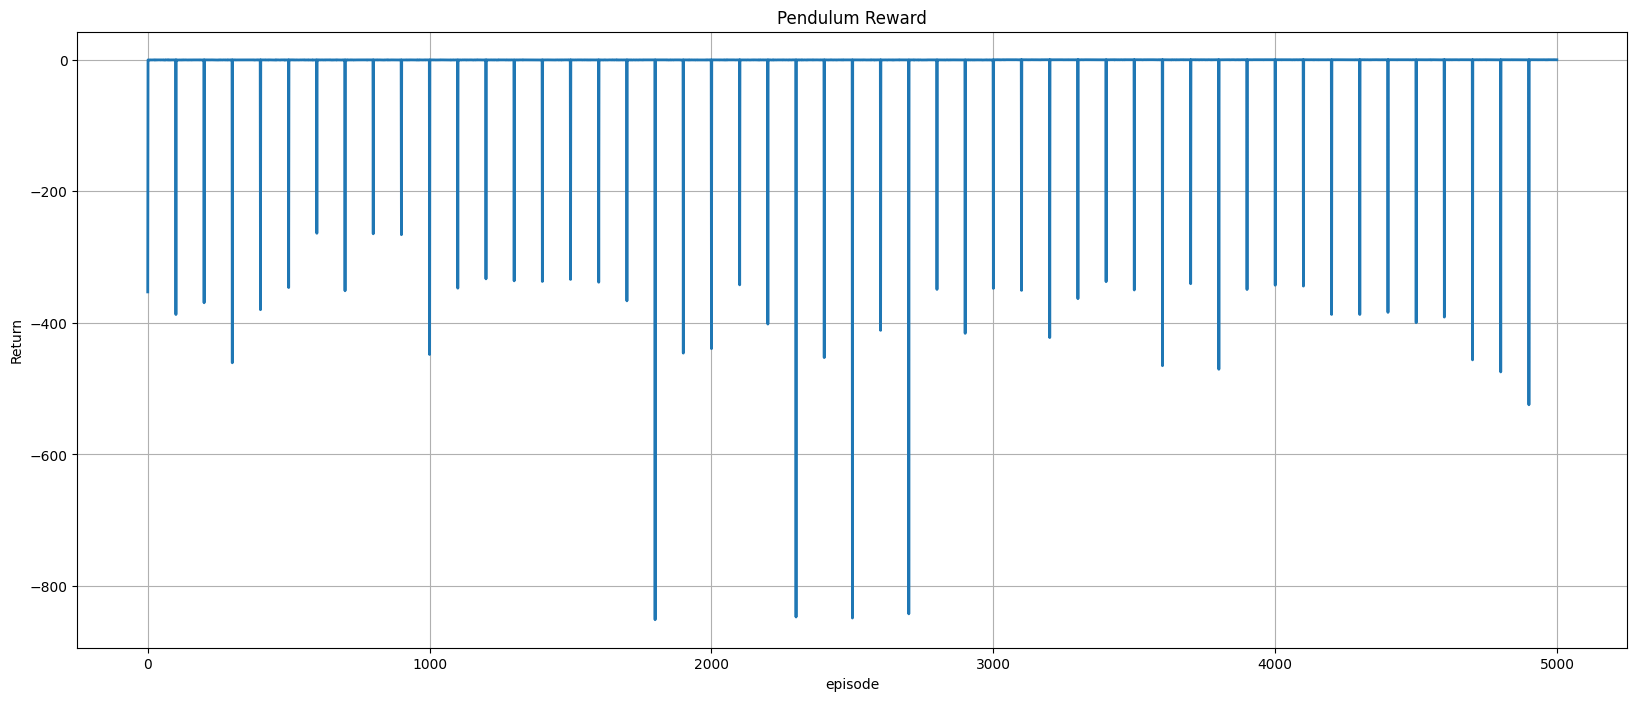

In [9]:
# p 0.03 lr 0.001
HORIZON = 200
GAMMA = 0.99
MU_P = 0
STD_DEV = 0.1

NUM_EPISODES = 5000

START = "up"
SEED = 42  
random.seed(SEED)
np.random.seed(SEED)

env =  PendulumEnv(horizon=HORIZON, gamma=GAMMA, friction = MU_P, render_mode="rgb_array")
s_dim = 15*15*15
a_dim = env.action_dim

net = nn.Sequential(
            nn.Linear(s_dim, a_dim, bias=False),
        )
model_desc = dict(
            layers_shape=[(s_dim, a_dim)]
        )
pol = DeepGaussianPolicy(
            parameters = np.load("/home/tedeschi_bpo/learn_RL/results/pendulum_friction/decay/test{0}_07_10-15_14_PG_200_pendulum_200_099_constant_0001_100_noclip__deep_gaussian_3375_std_1_noise_00/trial_0/policy_params.npy"),
            input_size=s_dim,
            output_size=a_dim,
            model=copy.deepcopy(net),
            model_desc=copy.deepcopy(model_desc),
            std_dev=STD_DEV,
            std_decay=0,
            std_min=1e-6
        )
dp = KernelDataProcessor()




all_episode_rewards = []
for i in tqdm(range(NUM_EPISODES)): # iterate over the episodes
    episode_rewards = []
    done = False
    if i % 1000 == 0 :
        print(f"current mu = {MU_P}")
    if i % 100 == 0:
        MU_P = round(MU_P + 0.01, 2)
        env =  PendulumEnv(horizon=HORIZON, gamma=GAMMA, friction = MU_P, render_mode="rgb_array")        
    env.reset(options={"start": "up"}, seed = i)
    if i % 100 == 0 :
        env.reset(options={"start": "down"}, seed = i)
    if i == 3000 :
        print(" ------- Simulating retrain at mu = 0.3")
        pol = DeepGaussianPolicy(
            parameters=np.load("/home/tedeschi_bpo/learn_RL/results/pendulum_friction/prova_like_lifelong/p03std{0.75}kl{0}_08_16-23_10_PG_200_pendulum_200_099_constant_0001_100_noclip__deep_gaussian_3375_std_075_noise_00/trial_0/policy_params.npy"),
            input_size=s_dim,
            output_size=a_dim,
            model=copy.deepcopy(net),
            model_desc=copy.deepcopy(model_desc),
            std_dev=STD_DEV,
            std_decay=0,
            std_min=1e-6
        )

    for t in range(HORIZON): # iterate over the steps until termination
        obs = env.state
        obs = dp.transform(obs)
        action = pol.draw_action(obs)
        obs, rew, done, _ = env.step(action)
        episode_rewards.append(rew * GAMMA ** t)
    all_episode_rewards.append(sum(episode_rewards))

mean_episode_reward = np.mean(all_episode_rewards)
std_episode_reward = np.std(all_episode_rewards)
print("Mean reward:", mean_episode_reward,
        "Std reward:", std_episode_reward)

plt.figure(figsize=(20, 8))
plt.plot(all_episode_rewards, linewidth=2, label="reward")
plt.title("Pendulum Reward")
plt.xlabel("episode")
plt.ylabel("Return")
plt.grid()
#plt.savefig("/home/tedeschi_bpo/learn_RL/presentation/lifelong/retrain03")



  0%|          | 0/5000 [00:00<?, ?it/s]

  0%|          | 2/5000 [00:00<06:06, 13.64it/s]

current mu = 0


 20%|██        | 1002/5000 [00:59<03:55, 16.96it/s]

current mu = 0.1


...

current mu = 0.3
 ------- Simulating retrain at mu = 0.3


 80%|████████  | 4002/5000 [03:56<00:59, 16.90it/s]

current mu = 0.4


100%|██████████| 5000/5000 [04:55<00:00, 16.91it/s]


Mean reward: -4.967774812922097 Std reward: 49.04563754354819


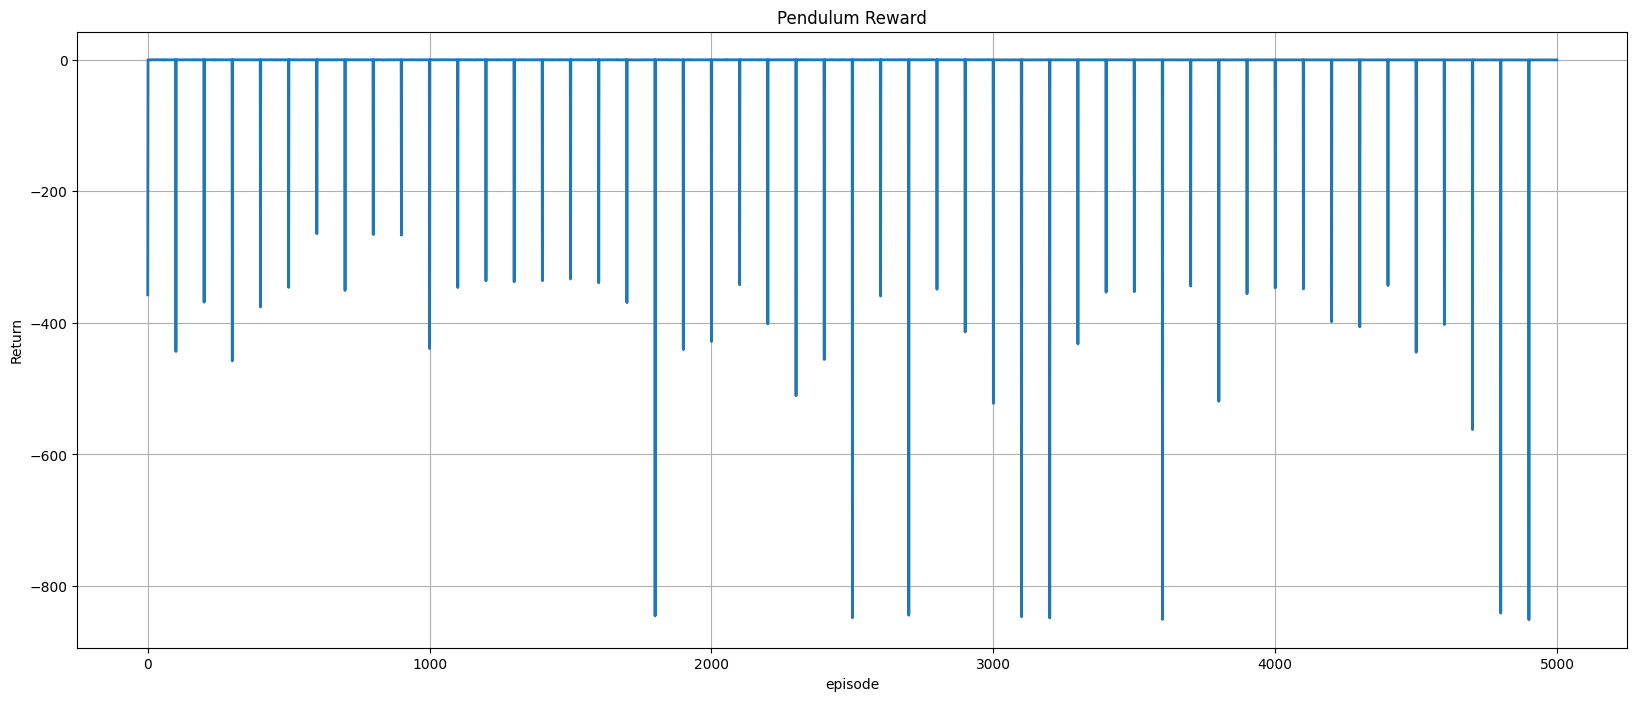

In [8]:
# LIFELONG STD 5 CONO FACENDO DECAY, MI PARE SOLO SU TARGET
HORIZON = 200
GAMMA = 0.99
MU_P = 0
STD_DEV = 0.25

NUM_EPISODES = 5000

START = "up"
SEED = 42  
random.seed(SEED)
np.random.seed(SEED)

env =  PendulumEnv(horizon=HORIZON, gamma=GAMMA, friction = MU_P, render_mode="rgb_array")
s_dim = 15*15*15
a_dim = env.action_dim

net = nn.Sequential(
            nn.Linear(s_dim, a_dim, bias=False),
        )
model_desc = dict(
            layers_shape=[(s_dim, a_dim)]
        )
pol = DeepGaussianPolicy(
            parameters = np.load("/home/tedeschi_bpo/learn_RL/results/pendulum_friction/decay/test{0}_07_10-15_14_PG_200_pendulum_200_099_constant_0001_100_noclip__deep_gaussian_3375_std_1_noise_00/trial_0/policy_params.npy"),
            input_size=s_dim,
            output_size=a_dim,
            model=copy.deepcopy(net),
            model_desc=copy.deepcopy(model_desc),
            std_dev=STD_DEV,
            std_decay=0,
            std_min=1e-6
        )
dp = KernelDataProcessor()




all_episode_rewards = []
for i in tqdm(range(NUM_EPISODES)): # iterate over the episodes
    episode_rewards = []
    done = False
    if i % 1000 == 0 :
        print(f"current mu = {MU_P}")
    if i % 100 == 0:
        MU_P = round(MU_P + 0.01, 2)
        env =  PendulumEnv(horizon=HORIZON, gamma=GAMMA, friction = MU_P, render_mode="rgb_array")        
    env.reset(options={"start": "up"}, seed = i)
    if i % 100 == 0 :
        env.reset(options={"start": "down"}, seed = i)
    if i == 3000 :
        print(" ------- Simulating retrain at mu = 0.3")
        pol = DeepGaussianPolicy(
            parameters=np.load("/home/tedeschi_bpo/learn_RL/results/pendulum_friction/provakl_cono_retrain/std{5}kl{0}decay_07_29-16_33_PG_200_pendulum_200_099_constant_001_100_noclip__deep_gaussian_3375_std_5_noise_00/trial_0/policy_params.npy"),
            input_size=s_dim,
            output_size=a_dim,
            model=copy.deepcopy(net),
            model_desc=copy.deepcopy(model_desc),
            std_dev=STD_DEV,
            std_decay=0,
            std_min=1e-6
        )

    for t in range(HORIZON): # iterate over the steps until termination
        obs = env.state
        obs = dp.transform(obs)
        action = pol.draw_action(obs)
        obs, rew, done, _ = env.step(action)
        episode_rewards.append(rew * GAMMA ** t)
    all_episode_rewards.append(sum(episode_rewards))

mean_episode_reward = np.mean(all_episode_rewards)
std_episode_reward = np.std(all_episode_rewards)
print("Mean reward:", mean_episode_reward,
        "Std reward:", std_episode_reward)

plt.figure(figsize=(20, 8))
plt.plot(all_episode_rewards, linewidth=2, label="reward")
plt.title("Pendulum Reward")
plt.xlabel("episode")
plt.ylabel("Return")
plt.grid()
#plt.savefig("/home/tedeschi_bpo/learn_RL/presentation/lifelong/retrain03")

